# Exercise 30.1b solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Initial conditions
D_0 = 0.0
A1_0 = 0.0
A2_0 = 0.0

# Rate constants
R_T = 1
k_on = 400
k_off = 50
f = 50
f_prime = 400
h = 8
h_prime = 6
g = 4


def rhs(t, y):
    """Right-hand side of the basic Razumova model."""
    D, A_1, A_2 = y
    R_off = R_T - D - A_1 - A_2

    dD_dt = k_on * R_off + f_prime * A_1 + g * A_2 - (k_off + f) * D
    dA1_dt = f * D + h_prime * A_2 - (f_prime + h) * A_1
    dA2_dt = h * A_1 - (h_prime + g) * A_2

    return [dD_dt, dA1_dt, dA2_dt]


# Solve
t_span = (0, 10)
t_eval = np.linspace(*t_span, 5000)
sol = solve_ivp(rhs, t_span, [D_0, A1_0, A2_0], t_eval=t_eval, method="RK45")

D = sol.y[0]
A_1 = sol.y[1]
A_2 = sol.y[2]
time = sol.t
# ----------------------------------------------

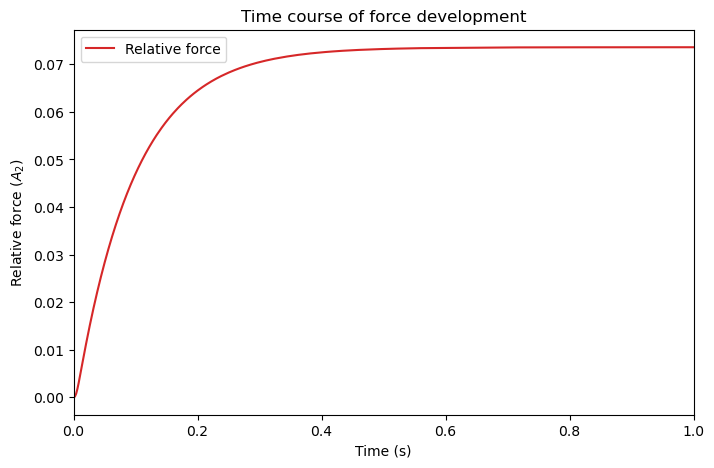

Steady-state force (A_2_max): 0.0736
k_dev = 10.00 1/sec


In [2]:
plt.figure(figsize=(8, 5))
plt.plot(time, A_2, label="Relative force", color="C3")
plt.xlabel("Time (s)")
plt.ylabel("Relative force ($A_2$)")
plt.title("Time course of force development")
plt.xlim(0, 1)
plt.legend()
plt.show()

f_max = A_2[-1]
f_63 = (1 - 1 / np.e) * f_max
idx = np.searchsorted(A_2, f_63)
t_63 = time[idx]
k_dev = 1 / t_63

print(f"Steady-state force (A_2_max): {f_max:.4f}")
print(f"k_dev = {k_dev:.2f} 1/sec")